# Interpreting decisions: text, images and proteins

> Train sysone's three applications on small tasks, then ask of each how good it is, where it goes wrong and why it answers as it does: metrics beyond accuracy, the worst mistakes, confusions and calibration, and attributions that colour the words, pixels and residues behind an answer.

- skip_exec: true
- skip_showdoc: true

A decision model that scores well can still be right for the wrong reasons, or wrong in ways the average hides. This tutorial trains one model per application and looks inside each, with three tools:

- **Metrics** ([metrics](../04a_metrics.ipynb)): accuracy alone says how often the answer is right. Macro-F1 and balanced accuracy weigh rare answers as much as common ones; the expected calibration error (ECE) says whether a 90% answer is right 90% of the time; and the area under the risk–coverage curve (AURC) says how much acting only on sure answers helps.
- **Interpretation** ([interpret](../09a_interpret.ipynb)), fastai's: the decisions with the largest losses, which answers get confused for which, and how confidence compares with being right.
- **Attributions**, in the style of [transformers-interpret](https://github.com/cdpierse/transformers-interpret): for one decision, how much each word, pixel or residue raised or lowered each option's probability.

The tasks are small and public, so everything runs on a laptop: emotions in tweets for the text application, handwritten digits and photos of hot dogs for the multimodal one, and where in the cell a protein lives for the protein one. The whole run takes about 25 minutes on an M3 Pro (MPS, fp32), and 17 when the feature caches of an earlier run are on disk, as they were for the outputs below, from a run on 2026-10-01. The first run also downloads about 4.3 GB of checkpoints: ModernBERT-large, ModernVBERT and ProtST.

::: {.callout-tip title="New to interpretability? Start here"}
Think of each model as a student who has just sat an exam. The metrics are its report card: how often it is right, on rare questions as well as common ones, and whether it knows when it is unsure. Interpretation goes through the marked paper: the worst mistakes, the answers it mixes up, and whether "90% sure" means right nine times in ten. Attributions ask the student *why*: which words, which parts of the picture, which stretch of the protein made it answer as it did.

Four words come back throughout:

- **Probability, or confidence.** For each question the model shares out 100% among the options. The option with the largest share is its *answer*, and that share is its *confidence*.
- **Log-odds.** The same belief on another scale, $\log \frac{p}{1-p}$: 0 at 50%, +1 at 73%, +2 at 88%, +3 at 95%, +4.6 at 99%, and the same below zero for the same chances against. Each +1 multiplies the odds by e ≈ 2.7. Attributions are measured in log-odds, since they keep moving where a probability is pinned near 0 or 100%.
- **Loss.** How surprised the model is by the right answer: −log of the probability it gave it. It is 0 at 100%, 0.69 at 50% and 4.6 at 1%; a blind guess among the six emotions scores log 6 ≈ 1.79.
- **Gold.** The right answer, as the dataset labels it.

Each figure and table below comes with a note on how to read it.
:::

## Setup

In [ ]:
import gc, io, json, logging, random, resource, sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib_inline.backend_inline import set_matplotlib_formats
from IPython.display import HTML, Image as DisplayImage, display
from PIL import Image as PILImage
import datasets, huggingface_hub, transformers
from huggingface_hub import hf_hub_download, snapshot_download
from transformers.trainer_callback import PrinterCallback, ProgressCallback
from sysone.data import TypedDecisions
from sysone.datasets import from_classification
from sysone.metrics import *
from sysone.interpret import Interpretation, attribution_path, occlusion

In [ ]:
logging.getLogger("transformers").setLevel(logging.ERROR)
datasets.logging.set_verbosity_error(); huggingface_hub.utils.logging.set_verbosity_error()
datasets.disable_progress_bars(); transformers.utils.logging.disable_progress_bar()
set_matplotlib_formats("png"); plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
work = Path("interpretation")            # the images this notebook saves, and the feature caches
t_start = time.time()
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"torch {torch.__version__} · transformers {transformers.__version__} · {device}")

torch 2.14.0 · transformers 5.17.0 · mps


In [ ]:
def quiet(learn):
    "The learner, without the Trainer's per-step log lines in the outputs (`learn.recorder` still has them)"
    for cb in (PrinterCallback, ProgressCallback): learn.trainer.remove_callback(cb)
    return learn

def release():
    "Hand back the memory of deleted models"
    gc.collect()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def memory() -> str:
    "The process's peak resident memory, and what the MPS driver holds now"
    release()
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / (2**30 if sys.platform == "darwin" else 2**20)    # bytes on macOS, KB on Linux
    mps = f" · MPS driver {torch.mps.driver_allocated_memory() / 2**30:.1f} GB" if torch.backends.mps.is_available() else ""
    return f"peak RSS {rss:.1f} GB{mps}"

def show_figure(fig, dpi=90):
    "Display a figure as PNG and close it"
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight"); plt.close(fig)
    display(DisplayImage(buf.getvalue(), format="png"))

def spearman(a, b) -> float:
    "Spearman's rank correlation, ties at their mean rank"
    return float(pd.Series(a).rank().corr(pd.Series(b).rank()))

## Emotions in tweets

[dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion) holds English tweets labelled with one of six emotions: sadness, joy, love, anger, fear and surprise. As a typed decision, each tweet is the state of a record, and its question is a choice among the six. The training set takes 500 tweets of each emotion, so that rare emotions are not drowned out, and the 600 tweets scored, and 300 more for calibrating, come from the dataset's validation split as they are, where joy and sadness are common and surprise is rare:

In [ ]:
emo = datasets.load_dataset("dair-ai/emotion", "split")
EMOTIONS = emo["train"].features["label"].names

def per_label(ds, n, seed=0):
    "n rows of each label, in the dataset's order"
    rng, by = random.Random(seed), {}
    for i in rng.sample(range(len(ds)), len(ds)):
        y = ds[i]["label"]
        if len(by.setdefault(y, [])) < n: by[y].append(i)
        if len(by) == len(EMOTIONS) and all(len(v) == n for v in by.values()): break
    return ds.select(sorted(i for v in by.values() for i in v))

ASK = "Which emotion does this text express?"
held = emo["validation"].shuffle(seed=0)
train = from_classification(per_label(emo["train"], 500), "text", "label", instructions=ASK, qid="emotion", prefix="train")
valid = from_classification(held.select(range(600)), "text", "label", instructions=ASK, qid="emotion", prefix="valid")
calib = from_classification(held.select(range(600, 900)), "text", "label", instructions=ASK, qid="emotion", prefix="calib")
print(len(train), "to train on ·", len(valid), "to score ·", len(calib), "to calibrate")
print(json.dumps(valid[0], indent=1))
pd.Series([r["gold"]["emotion"]["label"] for r in valid]).value_counts().rename("tweets scored")

3000 to train on · 600 to score · 300 to calibrate
{
 "id": "valid_000000",
 "state": "i feel for the kids of troubled homes and i feel for the ones who could change that around",
 "questions": {
  "emotion": {
   "type": "choice",
   "instructions": "Which emotion does this text express?",
   "criteria": [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
   ]
  }
 },
 "gold": {
  "emotion": {
   "label": "sadness"
  }
 }
}


joy         219
sadness     157
anger        88
fear         63
love         50
surprise     23
Name: tweets scored, dtype: int64

The text application's default is ModernBERT-large, frozen, under a head that reads each option's anchor vector, which the application caches so the head trains in seconds. A first try:

In [ ]:
from sysone.text import decision_learner as text_learner

In [ ]:
data = TypedDecisions(train, valid, calib)
torch.manual_seed(0)
frozen = quiet(text_learner(data, preset="macbook", per_device_train_batch_size=32, cache_dir=work / "cache"))
t0 = time.time()
frozen.fit_one_cycle(10, lr=1e-3)
frozen_accuracy = frozen.validate()["accuracy"]
print(f"the frozen default: accuracy {frozen_accuracy:.3f} on the 600 tweets, cached and trained in {time.time() - t0:.0f} s")
del frozen; release()

the frozen default: accuracy 0.453 on the 600 tweets, cached and trained in 21 s


That's 0.453 on six emotions, against 0.365 for always answering joy. An emotion is spread over a whole tweet, and the vector a frozen encoder puts at one option's anchor holds little of it. So this model trains the encoder too, with LoRA, in two passes over the tweets. `metrics=` adds macro-F1, balanced accuracy and the Matthews correlation to the columns the learner reports after every epoch:

In [ ]:
torch.manual_seed(0)
learn = quiet(text_learner(data, train="lora", head="mlp", preset="macbook", per_device_train_batch_size=16, per_device_eval_batch_size=32,
                           metrics=[F1Score(), BalancedAccuracy(), MatthewsCorrCoef()]))
t0 = time.time()
learn.fit_one_cycle(2, lr=1e-3)
print(f"trained in {(time.time() - t0) / 60:.1f} min · temperatures {learn.temperatures} · {memory()}")
pd.DataFrame(learn.recorder.metrics)[["epoch", "loss", "accuracy", "f1_score", "balanced_accuracy", "matthews_corrcoef", "ece"]].round(3)

trained in 5.4 min · temperatures {'choice': 1.0956, 'choice:6-10': 1.0956} · peak RSS 1.0 GB · MPS driver 4.0 GB


,epoch,loss,accuracy,f1_score,balanced_accuracy,matthews_corrcoef,ece
0,1.0,0.817,0.708,0.675,0.742,0.638,0.054
1,2.0,0.644,0.768,0.736,0.774,0.705,0.075


The table has a row per epoch, a pass over the 3,000 training tweets, scored on the 600 held out. *loss* is the validation loss, the average surprise at the right emotion, which a blind guess would put at 1.79. *accuracy* is the share right. The next three weigh the six emotions alike, however common: *f1_score* is macro-F1, *balanced_accuracy* the average over the emotions of the share of each one found, and *matthews_corrcoef* a single score from −1 to 1, where 0 is chance and 1 perfect, which stays honest when one answer is far more common than another. *ece* is the calibration error, explained with the reliability diagram below. The second epoch improves every number but the calibration error, which rises from 0.054 to 0.075; the table below, scored with the temperatures fitted on the calibration tweets after training, has 0.060.

### How good is it?

`Interpretation.from_learner` reads the 600 scored tweets back as decisions, with the temperatures the learner fitted on the calibration tweets, and `metrics` makes a table of any metrics over them:

In [ ]:
interp = Interpretation.from_learner(learn)
print(interp)
interp.metrics([accuracy, F1Score(), BalancedAccuracy(), top_k_accuracy, log_loss, brier_score, ece, aurc]).round(3)

Interpretation(Preds(600 rows: 600 choice · 0 unanswerable · calibrated) · 600 records)


,accuracy,f1_score,balanced_accuracy,top_k_accuracy,log_loss,brier_score,ece,aurc,rows
all,0.768,0.736,0.774,0.933,0.633,0.334,0.06,0.094,600


::: {.callout-tip title="What these metrics measure"}
- **accuracy**: the share of tweets given the right emotion.
- **f1_score** (macro-F1) and **balanced_accuracy**: the same question asked of each emotion separately, then averaged, so surprise, with 23 tweets, counts as much as joy, with 219. A model that neglects the rare answers can have a high accuracy and a low macro-F1.
- **top_k_accuracy**: the share of tweets whose right emotion is among the model's two likeliest.
- **log_loss**: the average loss. Lower is better, and a blind guess among six scores 1.79.
- **brier_score**: the squared distance between the six probabilities and the right answer, summed over the emotions: 0 is perfect, and 2 is all the probability on one wrong emotion.
- **ece**: the calibration error, explained with the reliability diagram below: whether a 90% answer is right 90% of the time.
- **aurc**: the area under the risk–coverage curve. Picture a model that may hand a tweet to a person when it is unsure: act on its surest 1%, 2%, … up to all of them, and average the error rate of the tweets acted on. If its sureness separates right from wrong, the AURC is far below the error rate; if not, it is about the same.
:::

Three tweets in four get the right emotion (0.768), and the gold is among the two likeliest in 93% (`top_k_accuracy`). Macro-F1, 0.736, sits below accuracy because the model answers love and fear too often: fewer than half of its answers *love* are right (the report below). Balanced accuracy, 0.774, sits above it, since the rare emotions are found well when they occur. The area under the risk–coverage curve, 0.094, is well below the error rate, 0.232. The model is wrong mostly when it is unsure, so acting only on its surest answers would avoid many of its mistakes.

### Where is it wrong?

The confusion matrix, each row normalised to the gold emotion's tweets, says which emotions it mistakes for which:

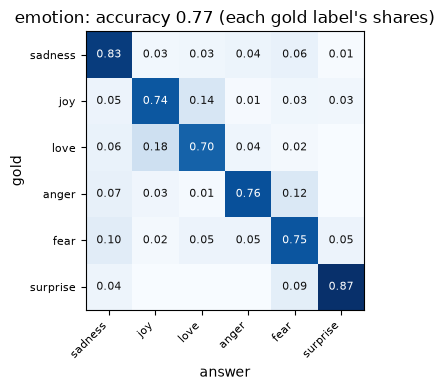

In [ ]:
interp.plot_confusion_matrix(normalize=True)

::: {.callout-tip title="How to read a confusion matrix and its report"}
Rows are the right emotion, columns the model's answer. Here each row is normalised: a cell is the share of that row's tweets given that answer, so each row sums to 1, the diagonal is the share of each emotion recognised, and the darker the cell, the larger the share. Off the diagonal, read a cell along its row: the 0.14 in row *joy*, column *love*, means 14% of the joyful tweets were taken for love.

The report below it gives three numbers per emotion. Think of a smoke alarm. *Recall* is the share of real fires it catches: of the tweets whose emotion is love, the share the model called love. *Precision* is the share of its alarms that are real fires: of the tweets it called love, the share that are. *F1* is high only when both are, and *support* is how many tweets have the emotion. *macro avg* averages the emotions alike, and *weighted avg* weighs them by their support.
:::

In [ ]:
print(interp.most_confused()[:5])
interp.classification_report().round(3)

[('joy', 'love', 31), ('joy', 'sadness', 11), ('anger', 'fear', 11), ('sadness', 'fear', 10), ('love', 'joy', 9)]


,precision,recall,f1,support
gold,,,,
sadness,0.828,0.828,0.828,157
joy,0.905,0.740,0.814,219
love,0.467,0.700,0.560,50
anger,0.827,0.761,0.793,88
fear,0.603,0.746,0.667,63
surprise,0.667,0.870,0.755,23
macro avg,0.716,0.774,0.736,600
weighted avg,0.796,0.768,0.776,600


Joy is the emotion it gets wrong most, and mostly as love: 31 tweets, 14% of the joyful ones, while love is read as joy only 9 times. Sadness and anger both slip towards fear. Per emotion, love's recall, 0.70, is fine, but its precision is 0.47.

The six tweets with the largest losses, the confident mistakes:

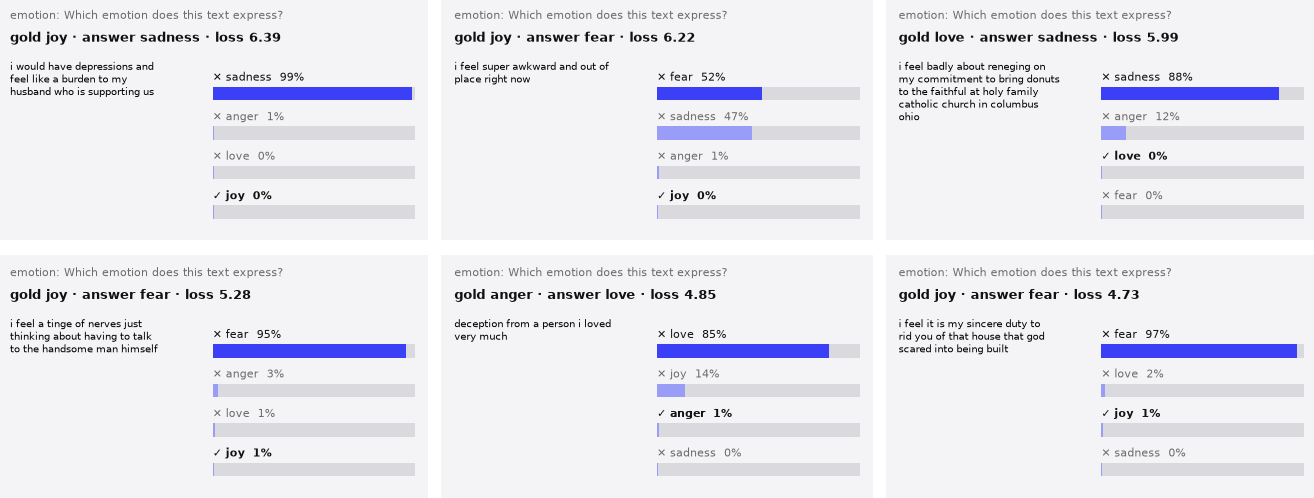

In [ ]:
interp.plot_top_losses(6)

::: {.callout-tip title="How to read a card"}
Each card is one decision. The grey line is the question, and the bold line gives the gold, the model's answer and the loss. On the left is the input; on the right, the likeliest options with their probabilities as bars. The dark blue bar is the model's answer, ✓ marks the gold in bold, and ✕ the wrong options. The loss is −log of the gold's probability, so the first card's 6.39 means the right answer, joy, got e^−6.39 ≈ 0.2% of the probability: the model was sure of something else.
:::

Several of the confident mistakes look like the dataset's own. *i would have depressions and feel like a burden to my husband who is supporting us* is labelled joy, and the model says sadness at 99%. *deception from a person i loved very much* is labelled anger, and the model says love. Finding labels like these is what fastai's `plot_top_losses` is used for, too. The reliability diagram compares how sure the answers are with how often they are right:

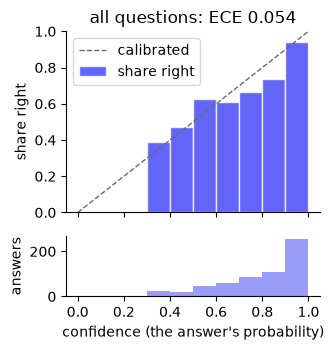

In [ ]:
interp.plot_calibration()

::: {.callout-tip title="How to read a reliability diagram, and what ECE is"}
A weather forecaster is *calibrated* when, of all the days they gave a 70% chance of rain, it rained on about 70%. A model is calibrated in the same way when, of the answers it gives at 70%, about 70% are right. The diagram checks this. It sorts the answers into ten bins by their confidence, the x axis, and each bar shows the share right in its bin, the y axis. The dashed diagonal is perfect calibration: a bar under it is *overconfident*, right less often than it claims, and a bar over it is *underconfident*. The histogram below counts the answers in each bin, since a bar over a handful of answers says little.

The *expected calibration error* (ECE) sums the diagram up. In each bin it takes the gap between the average confidence and the share right, and averages the gaps over the bins, weighted by how many answers each holds. With $n_b$ of the $N$ answers in bin $b$:

$$\mathrm{ECE} = \sum_b \frac{n_b}{N}\,\big|\,\mathrm{acc}_b - \mathrm{conf}_b\,\big|$$

0 is perfect, and 0.05 means the stated confidence is off by 5 points on average. Calibration is honesty, not skill, so it is read beside accuracy: a model that answered every tweet *joy* at 36%, the share of joyful tweets, would be perfectly calibrated and right only 36% of the time.
:::

The calibration error is 0.054 over ten bins (0.060 over the fifteen of the metrics table). The bars sit a little under the diagonal from 0.6 to 0.9, so answers given 80 to 90% are right 74% of the time, and most answers fall in the surest bin, where they are right about as often as they claim.

### Why did it answer that?

`interp.explain(i)` explains decision `i`. Through a sysone model it uses integrated gradients by default, and `method="occlusion"` removes each word in turn and asks again. Both explain an option's *log-odds*, log p/(1 − p), which don't saturate: an answer at 99.9% still has log-odds that move, where its probability barely can. Occlusion first, on a tweet answered right: each row is an option, its words green where they raised that option's log-odds and red where they lowered them, each row's shades relative to its largest score, its scale. A word's number shows when the pointer rests on it.

::: {.callout-tip title="How to read an attribution"}
The first line says what is explained: the question, the model's answer with its probability, the gold, the method (`occlusion`, or `ig` for integrated gradients) and what the numbers measure, log-odds. Each row is one option, the gold marked ✓:

- **p** is the option's probability.
- **scale** is the row's largest number, as a size: a word coloured at full strength moved the option's log-odds by that much.
- **words** is the text. A green word spoke for the option and a red one against it; the stronger the colour, the larger its share of the scale. Grey words are the template's markers, and ▸ marks the anchors where the model reads each option. Resting the pointer on a word shows its number.
- With integrated gradients there are two more columns. **Δ** is how far the option's log-odds moved from the baseline, a row with every word blanked, to the real row. **Σ** is the sum of the row's attributions. The two must be equal, as a receipt's items must add up to its total, and ⚠ marks the rows where they aren't.

Colours are relative to each row's scale, so read the scale before the colours: a deep green under a scale of 0.1 means less than a pale green under a scale of 5.
:::

In [ ]:
p = interp.preds
by_conf = [int(i) for i in np.argsort(-p.conf)]
def pick(emotion, right=True):
    "The surest decision on a tweet of `emotion` that is answered right (or wrong)"
    return next(i for i in by_conf if p.option_keys[i][p.labels[i]] == emotion and bool(p.correct[i]) == right)
i_love, i_fear = pick("love"), pick("fear")
i_worst = int(interp.top_losses(1)[1][0])
interp.explain(i_love, method="occlusion")

option,p,scale,words
love ✓,0.99,5.5,i feel loyal to skirtsports


In [ ]:
interp.explain(i_fear, method="occlusion")

option,p,scale,words
fear ✓,0.99,8.4,i feel so terrified to tell her


One word carries each answer: *loyal* for love, its log-odds falling by 5.5 without it, and *terrified* for fear, falling by 8.4. *feel* comes next, at 2.5 and 0.8, and the other words barely count. On the worst mistake, occlusion explains the answer it gave and the gold it missed:

In [ ]:
interp.explain(i_worst, method="occlusion")

option,p,scale,words
sadness,0.99,2,i would have depressions and feel like a burden to my husband who is supporting us
joy ✓,0.00,1.5,i would have depressions and feel like a burden to my husband who is supporting us


The model's sadness rests on *depressions* (2.0) and *burden* (0.9), and those same two words push joy down (−1.5 and −1.1). It read the tweet as a reader would.

Integrated gradients explains every option at once, and every token of the row, the question's and the options' too:

In [ ]:
ig_fear = interp.explain(i_fear)
ig_fear

option,p,Δ,Σ,scale,words
fear ✓,0.99,+6.53,+6.52,0.79,[CLS] choice question: Which emotion does this text express? [SEP] ▸ sadness ▸ joy ▸ love ▸ anger ▸ fear ▸ surprise [SEP] i feel so terrified to tell her [SEP]
anger,0.00,-4.20,-4.16,1,[CLS] choice question: Which emotion does this text express? [SEP] ▸ sadness ▸ joy ▸ love ▸ anger ▸ fear ▸ surprise [SEP] i feel so terrified to tell her [SEP]
sadness,0.00,-4.20,-3.16 ⚠,0.89,[CLS] choice question: Which emotion does this text express? [SEP] ▸ sadness ▸ joy ▸ love ▸ anger ▸ fear ▸ surprise [SEP] i feel so terrified to tell her [SEP]
surprise,0.00,-5.67,-4.64 ⚠,1,[CLS] choice question: Which emotion does this text express? [SEP] ▸ sadness ▸ joy ▸ love ▸ anger ▸ fear ▸ surprise [SEP] i feel so terrified to tell her [SEP]
love,0.00,-5.99,-5.78,0.71,[CLS] choice question: Which emotion does this text express? [SEP] ▸ sadness ▸ joy ▸ love ▸ anger ▸ fear ▸ surprise [SEP] i feel so terrified to tell her [SEP]
joy,0.00,-6.60,-5.91,0.77,[CLS] choice question: Which emotion does this text express? [SEP] ▸ sadness ▸ joy ▸ love ▸ anger ▸ fear ▸ surprise [SEP] i feel so terrified to tell her [SEP]


### How far to trust them

Integrated gradients comes with a check: its attributions must add up to the change of each option's log-odds from the baseline row, all `[PAD]`, to the tweet. The table above shows both, Δ the change and Σ the sum, and marks with ⚠ the options where they are far apart. For the answer, fear, they add up: Σ +6.52 against a change of +6.53. For sadness and surprise they miss by a fifth to a quarter. The words differ from occlusion's too: *feel*, *i* and *terrified* score about the same, 0.6 to 0.7, and the largest attributions in the row go to the question's and the options' tokens, which occlusion leaves alone. The integral is taken along a straight line from the baseline to the row, and `attribution_path` draws the answer's log-odds along it:

the largest step between neighbouring points 1/400 apart: 0.24 nats · in the zoom, between points 6.3e-05 apart: 0.01 nats


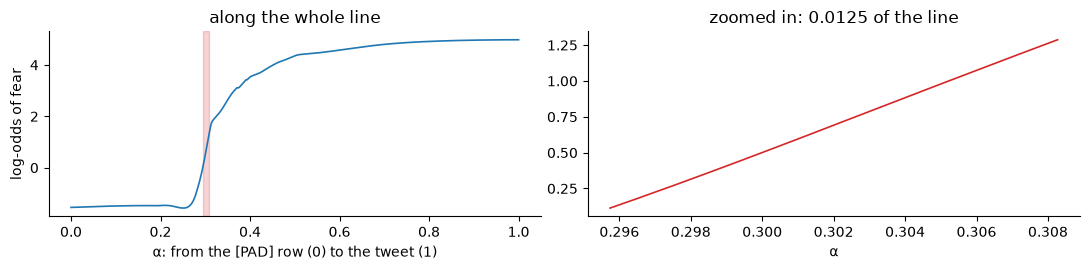

In [ ]:
path = learn.decider()
row = interp.records[int(p.case_idx[i_fear])]
alphas, along = attribution_path(path.model, path.builder, row["state"], row["questions"], "emotion", steps=400, temperatures=learn.temperatures)
j = int(np.abs(np.diff(along)).argmax())
zoom_a, zoom_f = attribution_path(path.model, path.builder, row["state"], row["questions"], "emotion", steps=200, temperatures=learn.temperatures,
                                  lo=alphas[max(0, j - 2)], hi=alphas[min(len(alphas) - 1, j + 3)])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 2.8))
a1.plot(alphas, along, lw=1.2); a1.set(xlabel="α: from the [PAD] row (0) to the tweet (1)", ylabel="log-odds of fear", title="along the whole line")
a1.axvspan(alphas[max(0, j - 2)], alphas[min(len(alphas) - 1, j + 3)], color="C3", alpha=0.2)
a2.plot(zoom_a, zoom_f, lw=1.2, color="C3"); a2.set(xlabel="α", title=f"zoomed in: {zoom_a[-1] - zoom_a[0]:.4f} of the line")
plt.tight_layout(); plt.show()
print(f"the largest step between neighbouring points 1/400 apart: {np.abs(np.diff(along)).max():.2f} nats · "
      f"in the zoom, between points {zoom_a[1] - zoom_a[0]:.1e} apart: {np.abs(np.diff(zoom_f)).max():.2f} nats")

On the left, the x axis runs from the row of `[PAD]` tokens, α = 0, to the tweet, α = 1, and the curve is the log-odds of fear at each point; the shaded band is the steepest stretch, which the right panel zooms into. Integrated gradients adds up the slope of this curve, so a smooth curve is one it can integrate, and a jagged one is a warning.

The line is smooth: no step between neighbouring points, 1/400 apart, is larger than 0.24, and zoomed in to 1/80 of the line the curve is straight. It is steep, though. The log-odds of fear stay near −1.5 until α ≈ 0.28, climb to about +2 by 0.32, and then rise more slowly to +5. More steps put more points on the climb. The same attribution with 16 to 256 steps:

In [ ]:
conv = {n: interp.explain(i_fear, options=["fear"], n_steps=n) for n in (16, 32, 64, 128, 256)}
pd.DataFrame({n: {"Δ, the change": a.f_input[0] - a.f_baseline[0], "Σ, the attributions' sum": sum(t[0] for t in a.totals().values()),
                  "steps per batch": a.batch_size} for n, a in conv.items()}).T.round(2).rename_axis("steps")

,"Δ, the change","Σ, the attributions' sum",steps per batch
steps,,,
16,6.53,6.18,30.0
32,6.53,6.52,30.0
64,6.53,6.34,30.0
128,6.53,6.25,30.0
256,6.53,6.62,30.0


From 16 steps to 256, the sum stays within 0.35 of the change, between 6.18 and 6.62 against 6.53. On this model, along this line, integrated gradients holds up; on the frozen encoder under the anchor head it didn't, since its line was jagged ([interpret](../09a_interpret.ipynb#how-far-to-trust-an-attribution)), and on the pixels below it won't. The second check matters more: does a method agree with occlusion, which only ever asks the model about real tweets? Over 40 tweets answered right, Spearman's correlation between each method's word scores and occlusion's, for the answer:

In [ ]:
def word_scores(a):
    "An attribution's scores for the tweet's words, for the answer"
    ws = a.words(segments=("state",)) if "tokens" in a.parts else [(t.strip(), float(s), "state") for t, s in zip(a.parts["words"].texts, a.parts["words"].scores[0])]
    return [w for w, _, _ in ws], np.array([s for _, s, _ in ws])

sample = [i for i in by_conf if p.correct[i]][::7][:40]
dec, agree, t0 = learn.decider(), {"integrated gradients, 32 steps": [], "integrated gradients, 128 steps": [], "gradient × input": [], "random scores": []}, time.time()
rng = np.random.default_rng(0)
for i in sample:
    (rec, qid), = interp.items([i])
    pred = p.option_keys[i][p.pred[i]]
    ow, os_ = word_scores(occlusion(dec, rec["state"], rec["questions"], qid, options=[pred]))
    for name, kw in (("integrated gradients, 32 steps", {}), ("integrated gradients, 128 steps", {"n_steps": 128}), ("gradient × input", {"method": "grad_x_input"})):
        w, s = word_scores(dec.explain(rec["state"], rec["questions"], qid, options=[pred], **kw))
        if w == ow: agree[name].append(spearman(s, os_))
    agree["random scores"].append(spearman(rng.permutation(len(os_)), os_))
print(f"{len(sample)} tweets in {time.time() - t0:.0f} s")
pd.DataFrame({k: {"median": np.median(v), "share above 0.5": np.mean(np.array(v) > 0.5), "tweets": len(v)} for k, v in agree.items()}).T.round(2)

40 tweets in 250 s


,median,share above 0.5,tweets
"integrated gradients, 32 steps",0.21,0.10,40.0
"integrated gradients, 128 steps",0.18,0.12,40.0
gradient × input,-0.03,0.08,40.0
random scores,-0.02,0.02,40.0


Spearman's correlation compares two rankings of the same words: 1 when both methods put them in the same order, 0 when the orders are unrelated, and −1 when one is the other reversed. *median* is the middle value over the 40 tweets, and *share above 0.5* how often the two rankings agree well. *random scores*, a ranking drawn at random, show what no agreement looks like.

The methods agree only loosely. Integrated gradients' word scores correlate with occlusion's at a median of 0.21, and above 0.5 for one tweet in ten; more steps don't change that (0.18), and gradient × input agrees no better than random scores. The two answer different questions. Occlusion asks what the model answers without a word, on a tweet that is still a tweet. Integrated gradients asks how the answer grows as every word fades in together from a row of `[PAD]`, which the model never sees. So for text, this tutorial relies on occlusion.

### Which words carry each emotion

One tweet's attribution explains one answer. Pooled over many, they show what the model has learned. Below, occlusion runs over every tweet the model answered right, and each word's fall in the answer's log-odds is averaged per emotion, over words seen in at least four tweets of it:

In [ ]:
t0, rows = time.time(), []
for i in [i for i in range(p.n) if p.correct[i]]:
    (rec, qid), = interp.items([i])
    w, s = word_scores(occlusion(dec, rec["state"], rec["questions"], qid, options=[p.option_keys[i][p.pred[i]]]))
    rows += [{"emotion": p.option_keys[i][p.labels[i]], "word": x.lower().strip(".,!?\"'"), "score": v} for x, v in zip(w, s)]
words = pd.DataFrame(rows)
print(f"{words.groupby('emotion').size().sum():,} word occlusions over {int(p.correct.sum())} tweets in {(time.time() - t0) / 60:.1f} min")
top_words = (words.groupby(["emotion", "word"]).score.agg(["mean", "count"]).query("count >= 4").reset_index()
                  .sort_values("mean", ascending=False).groupby("emotion").head(8))

8,630 word occlusions over 461 tweets in 2.5 min


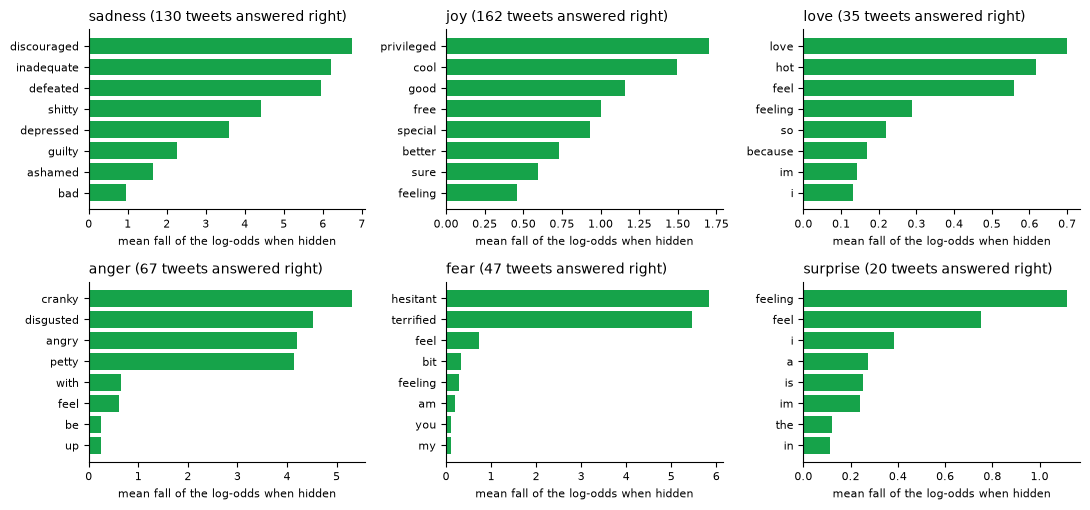

In [ ]:
#| code-fold: true
#| code-summary: figure code
n_right = pd.Series([p.option_keys[i][p.labels[i]] for i in range(p.n) if p.correct[i]]).value_counts()
fig, axs = plt.subplots(2, 3, figsize=(11, 5.2))
for ax, emotion in zip(axs.ravel(), EMOTIONS):
    t = top_words[top_words.emotion == emotion].iloc[::-1]
    ax.barh(t.word, t["mean"], color="#16a34a")
    ax.set_title(f"{emotion} ({n_right.get(emotion, 0)} tweets answered right)", fontsize=10, loc="left")
    ax.tick_params(labelsize=8); ax.set_xlabel("mean fall of the log-odds when hidden", fontsize=8)
plt.tight_layout(); plt.show()

Each panel is one emotion, with its eight words of largest mean fall: how far the emotion's log-odds fell, on average, when the word was hidden from a tweet the model got right, counting the words seen in at least four such tweets. Compare bars within a panel, and mind the axes across panels: sadness's top words move it by 6 to 7, love's by 0.7 at most, so love rests on no single word the way sadness rests on *discouraged*.

These are the model's emotion words, and they read like a thesaurus: *discouraged, inadequate, defeated, depressed* for sadness, *privileged, cool, good, free* for joy, *cranky, disgusted, angry, petty* for anger, *hesitant, terrified* for fear. Love has *love* and *hot*. Surprise has no word of its own: among the words seen in at least four of its 20 tweets answered right, none moves it much.

In [ ]:
del learn, interp, path, dec; release(); print(memory())

peak RSS 1.1 GB · MPS driver 0.0 GB


## Digits and hot dogs

The multimodal application reads an image beside the text, here with ModernVBERT, its default encoder. Each image is one 512-pixel tile, and the head trains on the anchors of a frozen encoder, as in the [ModernVBERT tutorial](02_modernvbert_images.ipynb). There are two tasks. The digits are a choice among ten, with 20 MNIST digits of each kind to train on and 20 more to score. The hot dogs are a noul, *the photo shows a hot dog*, with 40 food photos of each kind to train on and 40 more to score.

In [ ]:
from sysone.multimodal import decision_learner as mm_learner

In [ ]:
def mnist_records(per_class, seed=0, dest=work / "mnist"):
    "Choice records over MNIST: `per_class` images of each digit from its train split, and as many from its test split"
    rng, ds = random.Random(seed), datasets.load_dataset("ylecun/mnist")
    q = {"digit": {"type": "choice", "instructions": "Which digit is written in the image?", "criteria": [str(d) for d in range(10)]}}
    out = {}
    for split in ("train", "test"):
        labels, by = ds[split]["label"], {d: [] for d in range(10)}
        for i in rng.sample(range(len(labels)), len(labels)):
            if len(by[labels[i]]) < per_class: by[labels[i]].append(i)
            if all(len(v) == per_class for v in by.values()): break
        (dest / split).mkdir(parents=True, exist_ok=True); out[split] = []
        for d, idx in by.items():
            for i in idx:
                f = dest / split / f"{i}.png"
                if not f.exists(): ds[split][i]["image"].save(f)       # saved once: the feature cache keys on each file
                out[split].append({"id": f"mnist-{split}-{i}", "state": {"text": "", "image": str(f)}, "questions": q, "gold": {"digit": str(d)}})
        rng.shuffle(out[split])
    return out["train"], out["test"]

dtrain, dtest = mnist_records(20)
ddata = TypedDecisions.from_records(dtrain, valid=dtest, calib=0.2)
torch.manual_seed(0)
dlearn = quiet(mm_learner(ddata, image_side=512, preset="macbook", cache_dir=work / "cache", metrics=[F1Score(), top_k_accuracy]))
t0 = time.time()
dlearn.fit_one_cycle(30, lr=1e-3)
dinterp = Interpretation.from_learner(dlearn)
print(f"cached and trained in {time.time() - t0:.0f} s · {memory()}")
dinterp.metrics([accuracy, F1Score(), top_k_accuracy, log_loss, ece]).round(3)

cached and trained in 21 s · peak RSS 1.1 GB · MPS driver 1.4 GB


,accuracy,f1_score,top_k_accuracy,log_loss,ece,rows
all,0.87,0.869,0.93,0.42,0.057,200


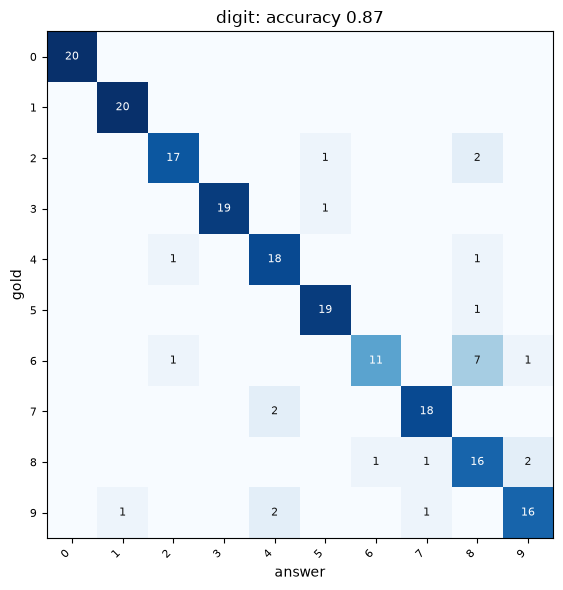

In [ ]:
dinterp.plot_confusion_matrix()

This matrix counts images instead of sharing them out: each row holds the 20 test images of one digit, so a 20 on the diagonal is a digit always read right. Row 6 has 11 sixes read right and 7 read as eights.

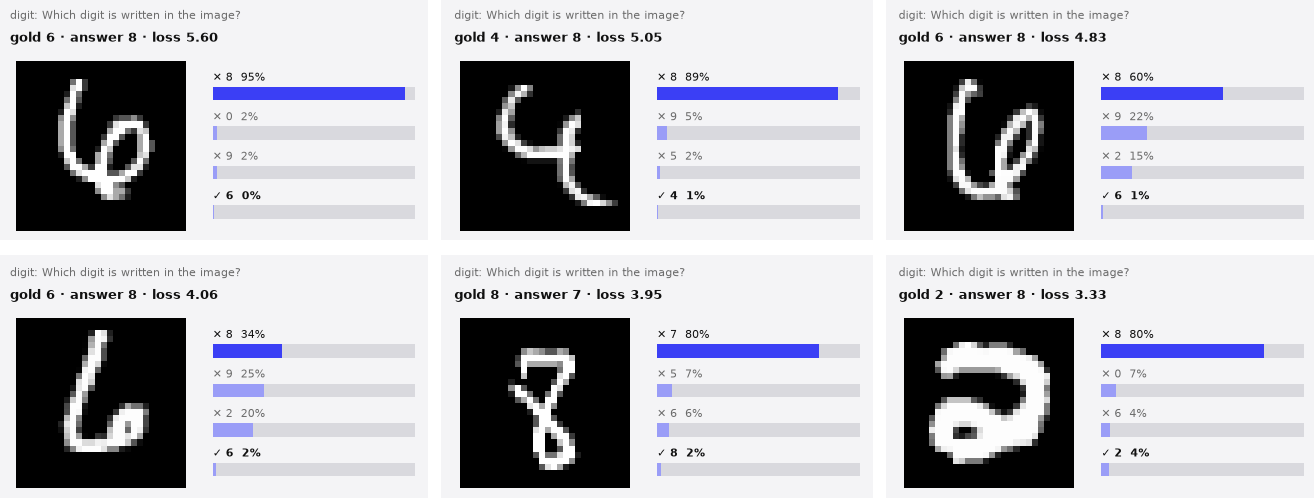

In [ ]:
dinterp.plot_top_losses(6)

0.87 of the digits are read right, against 0.10 for guessing, and the confusion matrix has one weak spot: seven of the twenty sixes are read as eights. The largest losses are mostly loopy sixes and fours read as eights.

For an image, integrated gradients moves the pixels along a line from a black image of the same size, while the question keeps its words. Each step is a forward and a backward pass through ModernVBERT's vision tower, and `attribute` measures what one step holds before it batches them. With its default 2 GB, a step per batch, an attribution of one digit for two options takes about three minutes on the laptop; `memory=4` lets two or three steps share a batch, and the same attribution takes well under a minute. The maps below are for the answer and the runner-up, green where pixels raised that digit's log-odds and pink where they lowered them:

a right 7: 27.7 s · steps per batch 3 · 7: Δ +10.36, Σ +8.52 · 4: Δ -5.51, Σ -3.26
a right 4: 26.6 s · steps per batch 3 · 4: Δ +13.61, Σ +4.36 · 7: Δ -9.09, Σ -13.93
the worst mistake: 26.6 s · steps per batch 3 · 8: Δ +3.55, Σ -12.69 · 0: Δ +5.42, Σ +13.38


option,p,Δ,Σ,
7 ✓,1.00,+10.36,+8.52 ⚠,
4,0.00,-5.51,-3.26 ⚠,

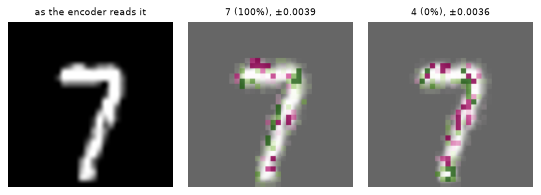

In [ ]:
dp = dinterp.preds
def pick_digit(d, right=True):
    "The surest decision on a digit `d`, answered right (or the surest wrong one)"
    return next(int(i) for i in np.argsort(-dp.conf) if dp.option_keys[i][dp.labels[i]] == d and bool(dp.correct[i]) == right)
top2 = lambda i: [int(o) for o in np.argsort(-dp.probs[i])[:2]]
digit_ig = {}
for name, i in (("a right 7", pick_digit("7")), ("a right 4", pick_digit("4")), ("the worst mistake", int(dinterp.top_losses(1)[1][0]))):
    t0 = time.time(); digit_ig[name] = dinterp.explain(i, options=top2(i), memory=4)
    a = digit_ig[name]
    print(f"{name}: {time.time() - t0:.1f} s · steps per batch {a.batch_size} · " +
          " · ".join(f"{a.keys[o]}: Δ {a.f_input[j] - a.f_baseline[j]:+.2f}, Σ {sum(t[j] for t in a.totals().values()):+.2f}" for j, o in enumerate(a.options)))
digit_ig["a right 7"]

::: {.callout-tip title="How to read an image attribution"}
The first panel is the image as the encoder reads it, here one 512-pixel tile. Each next panel is one option's map over it, titled with the option, its probability, and ± the attribution at which the colours reach full strength. Green marks pixels that raised the option's log-odds and pink pixels that lowered them; where pixels did neither, the image shows through, faded, which is why black looks grey. The map is averaged over square cells 1/32 of the image wide, and its colours stop growing at the 98th percentile of its values, so that a few extreme cells don't wash out the rest. Each map has its own scale, given in its title.
:::

Here green and pink cells sit side by side along the seven's strokes, at up to ±0.004 per pixel, and the map for four looks much the same: the maps trace where the ink is more than what makes it a seven. The ⚠ on both rows says not to read more into them, as the paragraphs below explain.

option,p,Δ,Σ,
4 ✓,1.00,+13.61,+4.36 ⚠,
7,0.00,-9.09,-13.93 ⚠,

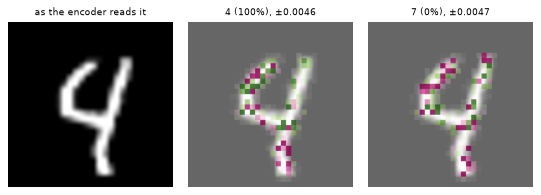

In [ ]:
digit_ig["a right 4"]

option,p,Δ,Σ,
8,0.95,+3.55,-12.69 ⚠,
0,0.02,+5.42,+13.38 ⚠,

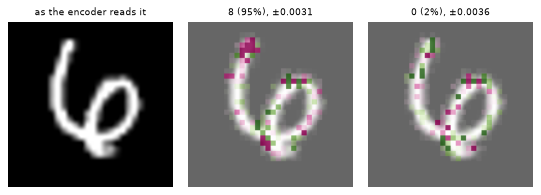

In [ ]:
digit_ig["the worst mistake"]

How much of the decision is the image's? With `inputs=["tokens", "pixels"]`, the row's tokens move along their line from `[PAD]` together with the pixels, and `by_segment` splits the answer's attribution between the question, the options and the image:

In [ ]:
share = dinterp.explain(pick_digit("7"), options=["7"], inputs=["tokens", "pixels"], memory=4)
share.by_segment().round(3)

,question,options,pixels
7,0.009,0.005,0.985


None of these attributions adds up, and some miss by more than the change itself. The seven's answer sums to +8.52 against a change of +10.36, the four's to +4.36 against +13.61, and the worst mistake's to −12.69 against +3.55. Along a line from a black image, the vision tower's output is too rough for 32 points, and the maps are speckled accordingly, green and pink side by side along the strokes. The joint attribution still says where the decision lives: 98.5% of the seven's attribution is in its pixels, 0.9% in the question's words and 0.5% in the options'.

Occlusion asks the decider about the digit with a 7-pixel square painted black, at every position in steps of 3 pixels, and each pixel's score is the mean fall of the log-odds over the squares that hid it:

64 images asked in 6 s


option,p,
7,1.00,
4,0.00,

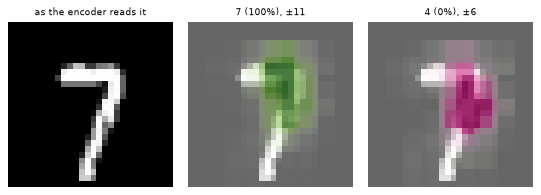

In [ ]:
(rec7, qid7), = dinterp.items([pick_digit("7")])
t0 = time.time()
o7 = occlusion(dlearn.decider(), rec7["state"], rec7["questions"], qid7, window=7, stride=3, options=top2(pick_digit("7")))
print(f"{len(range(0, 22, 3)) ** 2} images asked in {time.time() - t0:.0f} s")
o7

Occlusion's map reads like the others, with one difference: a cell's number is how far the option's log-odds *fall* when the squares covering it are painted black. Green means hiding it lowered the option, so the ink there spoke for it; pink means hiding it raised the option, so it spoke against. The titles give where the colours saturate: hiding the corner lowers the log-odds of seven by around 11 where the map is strongest, dividing its odds by some 60,000, and raises those of four by around 6.

Occlusion's map is coarser and clear. Hiding the corner where the seven's bar meets its stroke lowers the log-odds of seven by up to 11, and raises those of four: that corner is what tells this seven from a four, whose top is open. The 64 images took six seconds.

In [ ]:
del dlearn, dinterp, digit_ig; release()

The hot dogs are photos of food, a noul whose two options are false and true:

In [ ]:
src = Path(snapshot_download("truepositive/hotdog_nothotdog", repo_type="dataset"))
hq = {"hot_dog": {"type": "noul", "instructions": "The photo shows a hot dog."}}
rng, htrain, htest = random.Random(0), [], []
for cls, truth in (("hotdog", True), ("not_hotdog", False)):
    folder = next(f for f in sorted(src.rglob("*")) if f.is_dir() and f.parent.name == "train" and f.name.replace("_", "") == cls.replace("_", ""))
    files = sorted(folder.glob("*.jpg")); rng.shuffle(files)
    htrain += [{"id": f"{cls}-{f.stem}", "state": {"text": "", "image": str(f)}, "questions": hq, "gold": {"hot_dog": truth}} for f in files[:40]]
    htest += [{"id": f"{cls}-{f.stem}", "state": {"text": "", "image": str(f)}, "questions": hq, "gold": {"hot_dog": truth}} for f in files[40:80]]
rng.shuffle(htrain); rng.shuffle(htest)
hdata = TypedDecisions.from_records(htrain, valid=htest, calib=0.2)
torch.manual_seed(0)
hlearn = quiet(mm_learner(hdata, image_side=512, preset="macbook", cache_dir=work / "cache"))
hlearn.fit_one_cycle(30, lr=1e-3)
hinterp = Interpretation.from_learner(hlearn)
hinterp.metrics([accuracy, noul_auroc, log_loss, brier_score, ece]).round(3)

,accuracy,noul_auroc,log_loss,brier_score,ece,rows
all,0.938,0.995,0.13,0.088,0.044,80


A noul has a probability of *true*, and *noul_auroc* asks how well it ranks the photos: the chance that a random hot-dog photo gets a higher p(true) than a random other photo. 0.5 is a coin toss and 1 a perfect ranking, so 0.995 means nearly every hot dog ranks above nearly every other photo, even though a cut at 50% misplaces a few.

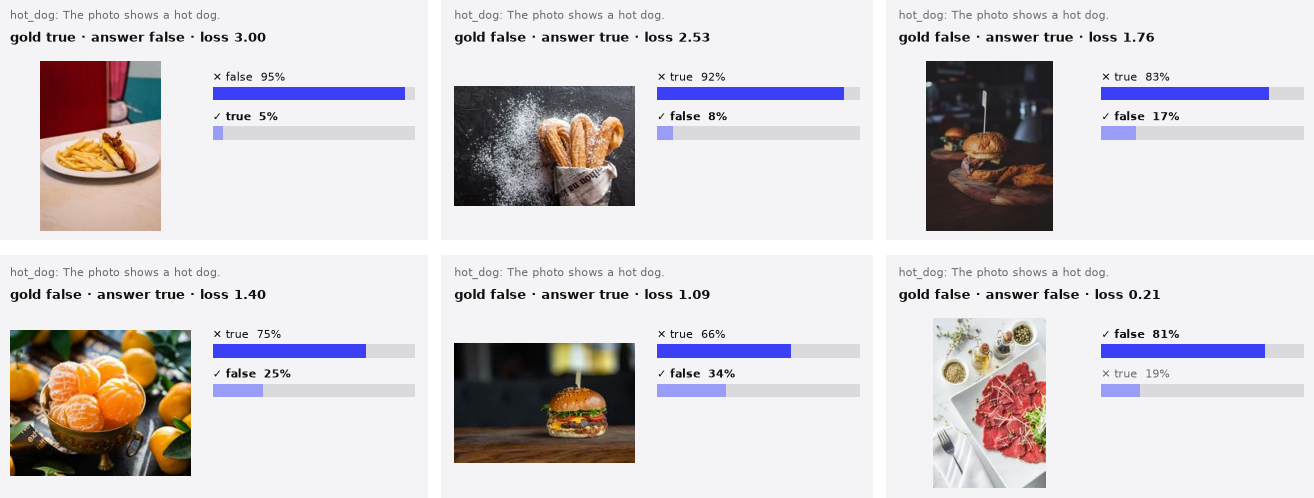

In [ ]:
hinterp.plot_top_losses(6)

The last card is answered right, *false* at 81%: with only five mistakes among the 80 photos, the sixth largest loss is a right answer the model wasn't sure of.

The photos are easier: 0.938 right, and p(true) ranks the hot dogs above nearly every other photo (AUROC 0.995). The confident mistakes are churros, a burger and mandarins taken for hot dogs, and a hot dog beside its fries taken for something else. Where in the photos does the model see a hot dog? Integrated gradients on the two photos it is surest show hot dogs, for the answer *true*:

option,p,Δ,Σ,
true ✓,1.00,+35.92,+18.07 ⚠,

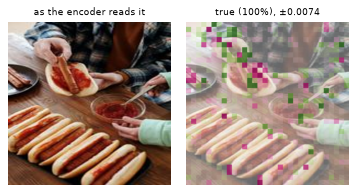

In [ ]:
hp = hinterp.preds
sure_dogs = [int(i) for i in np.argsort(-hp.probs[:, 1]) if hp.labels[i] == 1][:2]
hot_ig = [hinterp.explain(i, options=["true"], memory=4) for i in sure_dogs]
hot_ig[0]

option,p,Δ,Σ,
true ✓,1.00,+34.97,+28.73 ⚠,

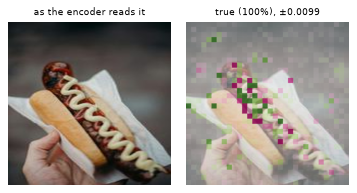

In [ ]:
hot_ig[1]

occlusion in 13 s


option,p,
true,1.00,

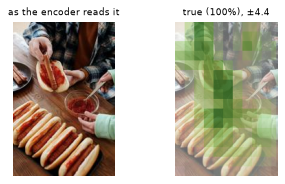

In [ ]:
(hrec, hqid), = hinterp.items(sure_dogs[:1])
t0 = time.time()
ho = occlusion(hlearn.decider(), hrec["state"], hrec["questions"], hqid, options=["true"])
print(f"occlusion in {time.time() - t0:.0f} s")
ho

Integrated gradients misses by a half and by a sixth here, +18.07 and +28.73 against changes of +35.92 and +34.97, and its maps scatter over the sausages. Occlusion's map, squares an eighth of the photo's longer side, is clear: hiding the hot dog in the hands lowers the log-odds the most.

In [ ]:
del hlearn, hinterp, hot_ig; release(); print(memory())

peak RSS 1.1 GB · MPS driver 3.1 GB


## Where proteins live

The protein application asks questions about a protein with [ProtST](https://arxiv.org/abs/2301.12040). ESM-1b reads the protein's residues as a side stream, PubMedBERT reads the question and its options, and a head scores each option against the protein (the [protein tutorial](04_protein_decisions.ipynb) explains the setup). The question is DeepLoc's: which of ten compartments a protein is found in. The model trains on 1,000 proteins from ProtST's localisation set, calibrates on 250 more, and is scored on another 250.

In [ ]:
from sysone.protein import clean_sequence, decision_learner as protein_learner, load_protst

In [ ]:
REPO_LOC, REPO_TPL = "Jiqing/ProtST-SubcellularLocalization", "Jiqing/subloc_template"
loc = {s: pd.read_parquet(hf_hub_download(REPO_LOC, f"data/{s}-00000-of-00001.parquet", repo_type="dataset")) for s in ("train", "validation")}
template = pd.read_csv(hf_hub_download(REPO_TPL, "subloc_template.csv", repo_type="dataset"))
KEYS = ["cell membrane", "cytoplasm", "endoplasmic reticulum", "Golgi apparatus", "lysosome or vacuole", "mitochondrion",
        "nucleus", "peroxisome", "plastid", "extracellular space"]
LOCATION = {"type": "choice", "instructions": "Where in the cell is this protein found?", "criteria": dict(zip(KEYS, template.name.str.strip()))}

def protein_records(df, n, seed, split):
    "n proteins of a split as records with the location question"
    rows = df.sample(n, random_state=seed)
    return [{"id": f"{split}-{i}", "state": {"sequence": clean_sequence(s)}, "questions": {"location": LOCATION}, "gold": {"location": KEYS[y]}}
            for i, (s, y) in enumerate(zip(rows.prot_seq, rows.localization))]

held_out = protein_records(loc["validation"], 500, 1, "validation")
pdata = TypedDecisions(protein_records(loc["train"], 1000, 0, "train"), held_out[:250], held_out[250:])
t0 = time.time()
protst = load_protst(device=device)
torch.manual_seed(0)
plearn = quiet(protein_learner(pdata, protst, preset="macbook", loss="soft_ce", cache_dir=work / "cache", per_device_train_batch_size=32,
                               metrics=[F1Score(), top_k_accuracy]))
plearn.fit_one_cycle(4, lr=1e-3)
pinterp = Interpretation.from_learner(plearn)
print(f"loaded, cached and trained in {(time.time() - t0) / 60:.1f} min · {memory()}")
pinterp.metrics([accuracy, F1Score(), BalancedAccuracy(), top_k_accuracy, log_loss, ece]).round(3)

loaded, cached and trained in 0.2 min · peak RSS 2.2 GB · MPS driver 4.1 GB


,accuracy,f1_score,balanced_accuracy,top_k_accuracy,log_loss,ece,rows
all,0.788,0.572,0.576,0.912,0.693,0.055,250


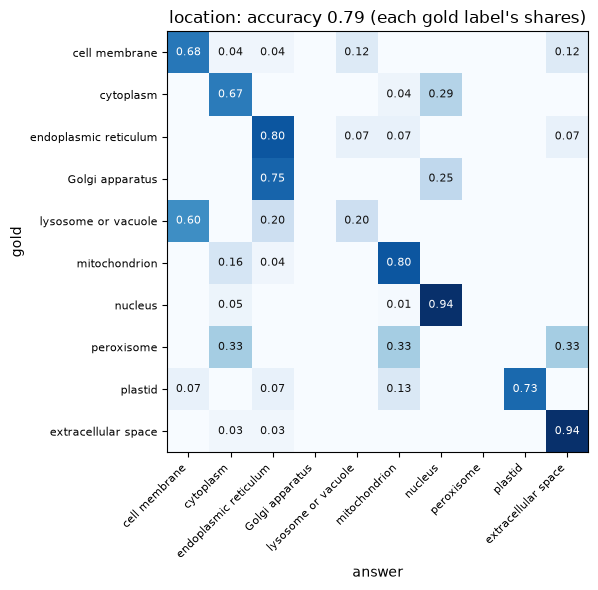

In [ ]:
pinterp.plot_confusion_matrix(normalize=True)

In [ ]:
print(pinterp.most_confused()[:6])
pinterp.classification_report().round(3)

[('cytoplasm', 'nucleus', 13), ('mitochondrion', 'cytoplasm', 4), ('nucleus', 'cytoplasm', 4), ('cell membrane', 'lysosome or vacuole', 3), ('cell membrane', 'extracellular space', 3), ('Golgi apparatus', 'endoplasmic reticulum', 3)]


,precision,recall,f1,support
gold,,,,
cell membrane,0.810,0.680,0.739,25
cytoplasm,0.732,0.667,0.698,45
endoplasmic reticulum,0.600,0.800,0.686,15
Golgi apparatus,0.000,0.000,0.000,4
lysosome or vacuole,0.200,0.200,0.200,5
mitochondrion,0.741,0.800,0.769,25
nucleus,0.843,0.938,0.888,80
peroxisome,0.000,0.000,0.000,3
plastid,1.000,0.733,0.846,15


Four answers in five are right (0.788), and the gold is among the two likeliest in 91%, but macro-F1 is 0.572. The model never places a protein in the Golgi apparatus (4 in the scored set) or the peroxisome (3) right, and only one lysosome in five. Rare compartments in a small training set are where it fails, which accuracy alone hides. Its most common mistake is a cytoplasmic protein placed in the nucleus, 13 of 45.

### The answer for no protein at all

An attribution measures a change from a baseline, so the baseline's own answer matters. For a protein, the baseline is the chain with every residue hidden, and here is what the model answers for a chain of `X`, the unknown residue, of every length:

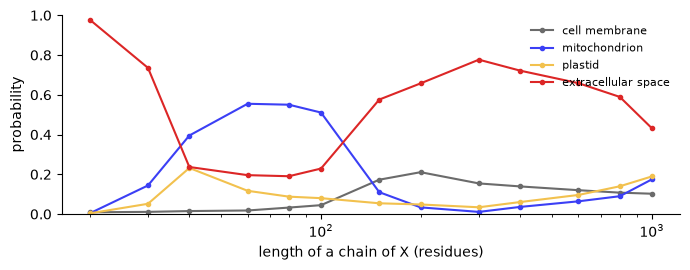

In [ ]:
pdec = plearn.decider(digits=None)            # unrounded probabilities: their logarithms are compared below
lengths = [20, 30, 40, 60, 80, 100, 150, 200, 300, 400, 600, 800, 1000]
blank = pd.DataFrame({n: a["location"]["probabilities"] for n, a in
                      zip(lengths, pdec.predict_batch([{"sequence": "M" + "X" * (n - 1)} for n in lengths], {"location": LOCATION}))}).T
fig, ax = plt.subplots(figsize=(7, 2.8))
for comp, c in zip([k for k in KEYS if blank[k].max() > 0.1], ("#6b6b6b", "#3b3ff5", "#f2c14e", "#dc2626", "#16a34a")):
    ax.plot(blank.index, blank[comp], "o-", ms=3, color=c, label=comp)
ax.set(xscale="log", xlabel="length of a chain of X (residues)", ylabel="probability", ylim=(0, 1)); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

Each line is one compartment's probability for a chain of nothing but the unknown residue X, at lengths from 20 to 1,000 residues, on a log scale where each labelled tick is ten times the last; only the compartments that reach 10% somewhere are drawn. A neutral baseline would give every compartment the same low probability at every length.

A chain of 20 unknown residues is secreted, to the model, at 98%, and one of 40 to 100 residues is mitochondrial, at 40% to 56%; from 150 residues on, it is secreted again, at 43% to 78%. So the baseline of a residue attribution is not neutral. It already has an answer, which depends on the chain's length, and hiding residues doesn't change the length. For a short protein the model calls secreted, hiding every residue barely changes the answer, so there is little for any attribution to find.

### Which residues decide

Occlusion hides 15 residues at a time, replacing them with `X`, in steps of 5, and records how far the log-odds of the answer fall; each residue's score is the mean over the windows that hid it. Integrated gradients moves the residues from ESM's `<mask>` to the protein. Both, for the protein the model places surest in the mitochondrion, and the one in the nucleus, each of at most 600 residues:

mitochondrion: 203 residues · occlusion in 4 s · integrated gradients in 9 s, Δ +9.70, Σ +8.79 · rank correlation of the two along the chain: 0.01
   occlusion's peak at residue 5: MLRNTIALRSFIRTQ (residues 1–15)
nucleus: 273 residues · occlusion in 7 s · integrated gradients in 15 s, Δ +11.80, Σ +7.76 · rank correlation of the two along the chain: 0.00
   occlusion's peak at residue 180: CHKVFPTGQALGGHKRCHYEG (residues 170–190)


option,p,
mitochondrion,1.00,

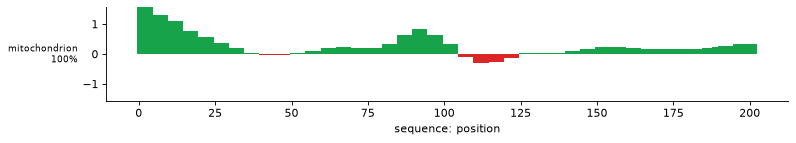

In [ ]:
pp = pinterp.preds
length = lambda i: len(pinterp.records[int(pp.case_idx[i])]["state"]["sequence"])
def pick_protein(comp, max_len=600):
    "The surest right decision on a protein of `comp` with at most `max_len` residues (else the shortest one answered right)"
    right = [int(i) for i in np.argsort(-pp.conf) if pp.option_keys[i][pp.labels[i]] == comp and pp.correct[i]]
    return ([i for i in right if length(i) <= max_len] or sorted(right, key=length))[0]
prot = {}
for comp in ("mitochondrion", "nucleus"):
    i = pick_protein(comp); (rec, qid), = pinterp.items([i])
    t0 = time.time(); occ = occlusion(pdec, rec["state"], rec["questions"], qid, kind="residues", window=15, stride=5, options=[comp])
    t1 = time.time(); ig = pinterp.explain(i, options=[comp], memory=4)
    prot[comp] = (occ, ig)
    print(f"{comp}: {length(i)} residues · occlusion in {t1 - t0:.0f} s · integrated gradients in {time.time() - t1:.0f} s, "
          f"Δ {ig.f_input[0] - ig.f_baseline[0]:+.2f}, Σ {sum(t[0] for t in ig.totals().values()):+.2f} · "
          f"rank correlation of the two along the chain: {spearman(occ.parts['sequence'].scores[0], ig.parts['stream:protein'].scores[0][1:-1]):.2f}")
    seq, so = occ.parts["sequence"].units, np.convolve(occ.parts["sequence"].scores[0], np.ones(9) / 9, mode="same")
    peak = int(np.argmax(so))
    print(f"   occlusion's peak at residue {peak + 1}: {''.join(seq[max(0, peak - 10):peak + 11])} (residues {max(0, peak - 10) + 1}–{min(len(seq), peak + 11)})")
prot["mitochondrion"][0]

Occlusion's bars run along the chain: green where hiding a stretch of 15 residues lowered the log-odds of mitochondrion, so that stretch speaks for the mitochondrion, and red where hiding it raised them. Each residue's bar is its mean over the windows that hid it.

The figure puts the two side by side along each chain, smoothed over 9 residues, and shows the first 40 residues as letters, each tile coloured by occlusion's score, above their hydropathy (Kyte–Doolittle, averaged over 9 residues):

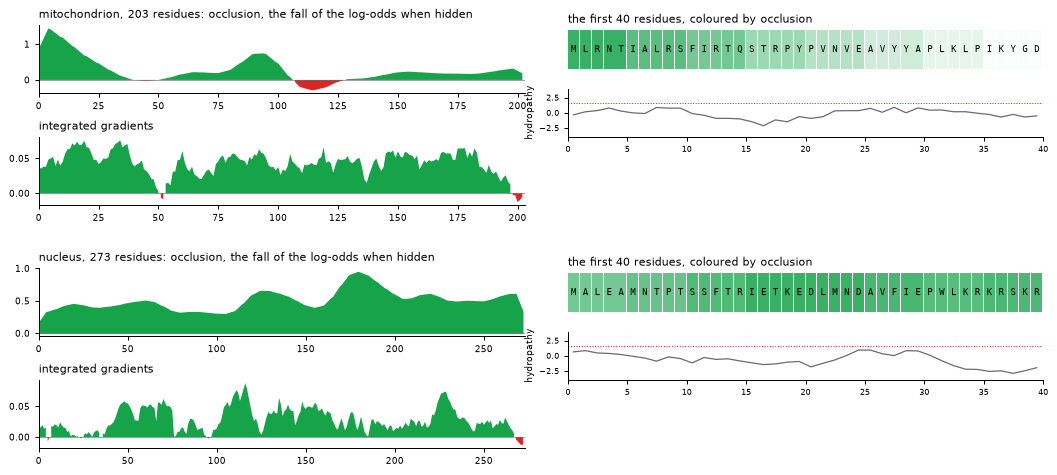

In [ ]:
#| code-fold: true
#| code-summary: figure code
KD = dict(A=1.8, R=-4.5, N=-3.5, D=-3.5, C=2.5, Q=-3.5, E=-3.5, G=-0.4, H=-3.2, I=4.5, L=3.8, K=-3.9, M=1.9, F=2.8, P=-1.6, S=-0.8, T=-0.7,
          W=-0.9, Y=-1.3, V=4.2)
smooth = lambda v, w=9: np.convolve(v, np.ones(w) / w, mode="same")
def track(ax, s, title):
    "One attribution along the chain, smoothed: green above zero, red below"
    v = smooth(s); x = np.arange(len(v))
    ax.fill_between(x, v, where=v > 0, color="#16a34a", lw=0); ax.fill_between(x, v, where=v <= 0, color="#dc2626", lw=0)
    ax.axhline(0, color="#6b6b6b", lw=0.5); ax.set_xlim(0, len(v)); ax.tick_params(labelsize=7); ax.set_title(title, fontsize=8.5, loc="left")
fig = plt.figure(figsize=(12, 5.4))
for k, (comp, (occ, ig)) in enumerate(prot.items()):
    seq, so, si = occ.parts["sequence"].units, occ.parts["sequence"].scores[0], ig.parts["stream:protein"].scores[0][1:-1]
    top = 0.97 - k * 0.5
    track(fig.add_axes([0.05, top - 0.17, 0.45, 0.14]), so, f"{comp}, {len(seq)} residues: occlusion, the fall of the log-odds when hidden")
    track(fig.add_axes([0.05, top - 0.40, 0.45, 0.14]), si, "integrated gradients")
    tx = fig.add_axes([0.54, top - 0.12, 0.44, 0.08]); tx.axis("off"); tx.set_xlim(0, 40); tx.set_ylim(0, 1)
    vmax = np.abs(so[:40]).max() or 1
    for x, (aa, v) in enumerate(zip(seq[:40], so[:40])):
        c = np.array((22, 163, 74) if v > 0 else (220, 38, 38)) / 255
        tx.add_patch(Rectangle((x, 0), 0.92, 1, color=(*c, min(1, abs(v) / vmax) * 0.85), lw=0))
        tx.text(x + 0.46, 0.5, aa, ha="center", va="center", fontsize=7, family="monospace")
    tx.set_title("the first 40 residues, coloured by occlusion", fontsize=8.5, loc="left")
    hx = fig.add_axes([0.54, top - 0.26, 0.44, 0.1])
    hx.plot(np.arange(40) + 0.46, smooth(np.array([KD.get(aa, 0.0) for aa in seq[:40]])), color="#6b6b6b", lw=1)
    hx.axhline(1.6, color="#dc2626", ls=":", lw=0.8); hx.set_xlim(0, 40); hx.set_ylim(-4, 4); hx.tick_params(labelsize=6); hx.set_ylabel("hydropathy", fontsize=7)
show_figure(fig)

On the left, each protein has two tracks along its chain, occlusion above and integrated gradients below, each smoothed over 9 residues: green above zero, red below. Their scales differ, since occlusion measures the fall when a whole stretch is hidden, and integrated gradients one residue's share. On the right are the first 40 residues as letters, each tile coloured by occlusion's score, above their *hydropathy*: how much a residue avoids water, positive for oily residues such as isoleucine (I, +4.5) and leucine (L, +3.8), negative for charged ones such as arginine (R, −4.5) and lysine (K, −3.9). A stretch whose average stays above the dotted line, 1.6, is oily enough to cross a cell membrane; neither protein's first residues come near it.

For the mitochondrial protein, occlusion's largest fall is over its first 15 residues, *MLRNTIALRSFIRTQ*. Three arginines among hydrophobic and hydroxylated residues, and no acidic one: that is the make-up of a mitochondrial targeting presequence, which sends a protein into the mitochondrion and is cut off there. Integrated gradients adds up for this protein (Σ +8.79 against a change of +9.70), but it spreads its attribution along the whole chain, and its ranking of the residues doesn't correlate with occlusion's (0.01). For the nuclear protein, occlusion peaks around residue 180, *CHKVFPTGQALGGHKRCHYEG*, a stretch rich in histidines, lysines and arginines. Integrated gradients peaks elsewhere and misses its change by a third (+7.76 against +11.80).

In [ ]:
del plearn, pinterp, prot, pdec, protst; release()
print(f"total run time {(time.time() - t_start) / 60:.1f} min · {memory()}")

total run time 17.2 min · peak RSS 2.2 GB · MPS driver 3.0 GB


## What we learned

- **Metrics beyond accuracy point at the problems.** Macro-F1 sits below accuracy where the model over-answers a class (love, for the tweets) or never gets a rare one right (the Golgi apparatus and the peroxisome, for the proteins). The area under the risk–coverage curve says whether acting only on sure answers would help.
- **The worst losses find bad labels and blind spots.** Tweets labelled joy that read as sadness, sixes read as eights, churros taken for hot dogs.
- **Check an attribution before reading it.** Integrated gradients added up on a tweet, but not on the pixels and for one protein in two, and even where it added up it disagreed with occlusion. Its Δ and Σ columns say when it doesn't add up.
- **Occlusion is the plain test, and it explains any backend.** It found the words each emotion rests on, the corner that makes a seven, and a mitochondrial presequence.
- **A baseline is a choice, and it has an answer of its own.** To this model, a chain of unknown residues is already a secreted protein.